In [1]:
# %%
"""
📌 Notebook: 07_transformer_model.ipynb

🎯 Purpose:
Train an advanced Transformer model for driving behavior classification.

🔥 Improvements:
- Correct label encoding (0–4)
- Deeper Transformer (2 encoder blocks)
- Class balancing (IMPORTANT)
- Learning rate scheduling
- Stronger dense layers
"""

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle
from sklearn.utils.class_weight import compute_class_weight

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [2]:
# %%
# GPU Setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU ready for Transformer.")
    except RuntimeError as e:
        print(e)

✅ GPU ready for Transformer.


In [3]:
# %%
# Safe folder creation
folders = [
    "../models",
    "../results/graphs",
    "../results/confusion_matrix"
]

for folder in folders:
    if os.path.isfile(folder):
        os.remove(folder)
    os.makedirs(folder, exist_ok=True)

In [4]:
# %%
# Load data
X_train = np.load("../processed_data/X_train.npy")
y_train = np.load("../processed_data/y_train.npy")
X_test = np.load("../processed_data/X_test.npy")
y_test = np.load("../processed_data/y_test.npy")

# ✅ FIX LABELS
y_train = y_train - 1
y_test = y_test - 1

print(f"✅ Data loaded. Shape: {X_train.shape}")

✅ Data loaded. Shape: (109326, 100, 9)


In [5]:
# %%
"""
🔹 Class Weights (IMPORTANT 🔥)
"""

classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("✅ Class weights:", class_weights)

✅ Class weights: {0: 1.1070987341772152, 1: 1.2029709507042254, 2: 0.8370415741520557, 3: 0.7594192831342039, 4: 1.3262889724614824}


In [6]:
# %%
"""
🔹 Transformer Encoder Block
"""

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    
    x = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)
    
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    x_ff = layers.Dense(ff_dim, activation="relu")(x)
    x_ff = layers.Dropout(dropout)(x_ff)
    x_ff = layers.Dense(inputs.shape[-1])(x_ff)

    return layers.LayerNormalization(epsilon=1e-6)(x + x_ff)

In [7]:
# %%
"""
🔹 Build Model
"""

inputs = layers.Input(shape=(X_train.shape[1], X_train.shape[2]))

# 🔥 TWO Transformer blocks
x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128)
x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128)

x = layers.GlobalAveragePooling1D()(x)

# 🔥 Stronger classifier head
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(5, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 100, 9)]     0           []                               
                                                                                                  
 multi_head_attention (MultiHea  (None, 100, 9)      9993        ['input_1[0][0]',                
 dAttention)                                                      'input_1[0][0]']                
                                                                                                  
 dropout (Dropout)              (None, 100, 9)       0           ['multi_head_attention[0][0]']   
                                                                                                  
 tf.__operators__.add (TFOpLamb  (None, 100, 9)      0           ['dropout[0][0]',            

In [8]:
# %%
"""
🔹 Callbacks (VERY IMPORTANT 🔥)
"""

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    "../models/best_transformer_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

# 🔥 Learning rate scheduler
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

In [9]:
# %%
"""
🔹 Training (WITH CLASS WEIGHTS)
"""

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    class_weight=class_weights,
    verbose=1
)

# Save history
with open('../results/transformer_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("✅ Transformer training complete.")

Epoch 1/60
3075/3075 [==============================] - 124s 38ms/step - loss: 0.9666 - accuracy: 0.5929 - val_loss: 0.7025 - val_accuracy: 0.7172 - lr: 0.0010
Epoch 2/60
3075/3075 [==============================] - 115s 37ms/step - loss: 0.6914 - accuracy: 0.7222 - val_loss: 0.6543 - val_accuracy: 0.7371 - lr: 0.0010
Epoch 3/60
3075/3075 [==============================] - 116s 38ms/step - loss: 0.6251 - accuracy: 0.7476 - val_loss: 0.6033 - val_accuracy: 0.7608 - lr: 0.0010
Epoch 4/60
3075/3075 [==============================] - 117s 38ms/step - loss: 0.5938 - accuracy: 0.7590 - val_loss: 0.5504 - val_accuracy: 0.7761 - lr: 0.0010
Epoch 5/60
3075/3075 [==============================] - 117s 38ms/step - loss: 0.5702 - accuracy: 0.7684 - val_loss: 0.5002 - val_accuracy: 0.7974 - lr: 0.0010
Epoch 6/60
3075/3075 [==============================] - 139s 45ms/step - loss: 0.5505 - accuracy: 0.7745 - val_loss: 0.5177 - val_accuracy: 0.7933 - lr: 0.0010
Epoch 7/60
3075/3075 [==================

In [10]:
# %%
"""
💾 Save Model
"""

model.save("../models/transformer_model.h5")
print("✅ Model saved.")

✅ Model saved.


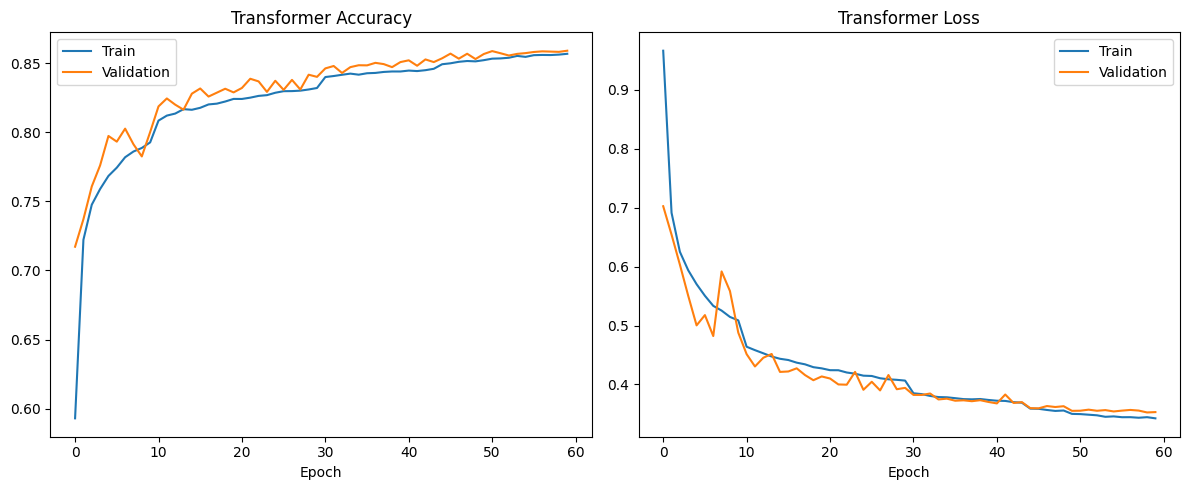

✅ Graph saved.


In [11]:
# %%
"""
📊 Plot Performance
"""

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Transformer Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Transformer Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('../results/graphs/transformer_performance_curves.png')
plt.show()

print("✅ Graph saved.")